# Data Visualisation (segmentation)
### Yuhui Cao

In [5]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = '1'
os.environ['HF_HOME'] = '/eresearch/hie/ycao891/Yuhui/hf_cache'
os.environ['TORCH_HOME'] = '/eresearch/hie/ycao891/Yuhui/torch_cache'

import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import random
import torch
import sys

%matplotlib inline
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
sys.path.append(str(Path.cwd().parent))

In [7]:
from utils.config import TREATMENT_GROUPS, REGION_GROUPS, TREATMENT_MAP, REGION_MAP, PatchConfig

In [8]:
ds_gen_root = Path("../Neuron Dataset Generated 1")
ds_root = Path('../Neuron Dataset')

In [9]:
from data.load_data import load_image_mask_pairs
base_ds = load_image_mask_pairs(ds_root, TREATMENT_GROUPS, REGION_GROUPS)

Loading data from: ../Neuron Dataset/HI/CA3


Loading data from: ../Neuron Dataset/HI/CA4


Loading data from: ../Neuron Dataset/HI/CA12


Loading data from: ../Neuron Dataset/HI/DG


Loading data from: ../Neuron Dataset/HI/PS1


...

Loading data from: ../Neuron Dataset/SHAM/PS1


Loading data from: ../Neuron Dataset/SHAM/PS2


Loading data from: ../Neuron Dataset/SHAM/TH1


Loading data from: ../Neuron Dataset/SHAM/TH2


Loaded 240 image/mask pairs



In [10]:
gen_ds = load_image_mask_pairs(ds_gen_root, TREATMENT_GROUPS, REGION_GROUPS)

Loading data from: ../Neuron Dataset Generated 1/HI/CA3


Loading data from: ../Neuron Dataset Generated 1/HI/CA4


Loading data from: ../Neuron Dataset Generated 1/HI/CA12


Loading data from: ../Neuron Dataset Generated 1/HI/DG


Loading data from: ../Neuron Dataset Generated 1/HI/PS1


...

Loading data from: ../Neuron Dataset Generated 1/SHAM/PS1


Loading data from: ../Neuron Dataset Generated 1/SHAM/PS2


Loading data from: ../Neuron Dataset Generated 1/SHAM/TH1


Loading data from: ../Neuron Dataset Generated 1/SHAM/TH2


Loaded 1248 image/mask pairs



In [11]:
import itertools

In [12]:
def check_class_balance(root, treatments, regions):
    for treatment, region in list(itertools.product(treatments, regions)):
        temp_path = root / treatment / region

        img_files = [x for x in temp_path.iterdir() if x.name.lower().endswith("_img.tif")]
        mask_files = [x for x in temp_path.iterdir() if x.name.lower().endswith("_masks.tif")]

        print(f"{treatment}-{region}: Images: {len(img_files)} | Masks: {len(mask_files)}")

In [13]:
check_class_balance(ds_root, TREATMENT_GROUPS, REGION_GROUPS)

HI-CA3: Images: 10 | Masks: 10
HI-CA4: Images: 10 | Masks: 10
HI-CA12: Images: 10 | Masks: 10
HI-DG: Images: 10 | Masks: 10
HI-PS1: Images: 10 | Masks: 10
HI-PS2: Images: 10 | Masks: 10
HI-TH1: Images: 10 | Masks: 10
HI-TH2: Images: 10 | Masks: 10
HI + HYPO-CA3: Images: 10 | Masks: 10
HI + HYPO-CA4: Images: 10 | Masks: 10
HI + HYPO-CA12: Images: 10 | Masks: 10
HI + HYPO-DG: Images: 10 | Masks: 10
HI + HYPO-PS1: Images: 10 | Masks: 10
HI + HYPO-PS2: Images: 10 | Masks: 10
HI + HYPO-TH1: Images: 10 | Masks: 10
HI + HYPO-TH2: Images: 10 | Masks: 10
SHAM-CA3: Images: 10 | Masks: 10
SHAM-CA4: Images: 10 | Masks: 10
SHAM-CA12: Images: 10 | Masks: 10
SHAM-DG: Images: 10 | Masks: 10
SHAM-PS1: Images: 10 | Masks: 10
SHAM-PS2: Images: 10 | Masks: 10
SHAM-TH1: Images: 10 | Masks: 10
SHAM-TH2: Images: 10 | Masks: 10


In [14]:
check_class_balance(ds_gen_root, TREATMENT_GROUPS, REGION_GROUPS)

HI-CA3: Images: 52 | Masks: 52
HI-CA4: Images: 52 | Masks: 52
HI-CA12: Images: 52 | Masks: 52
HI-DG: Images: 52 | Masks: 52
HI-PS1: Images: 52 | Masks: 52
HI-PS2: Images: 52 | Masks: 52
HI-TH1: Images: 52 | Masks: 52
HI-TH2: Images: 52 | Masks: 52
HI + HYPO-CA3: Images: 52 | Masks: 52
HI + HYPO-CA4: Images: 52 | Masks: 52
HI + HYPO-CA12: Images: 52 | Masks: 52
HI + HYPO-DG: Images: 52 | Masks: 52
HI + HYPO-PS1: Images: 52 | Masks: 52
HI + HYPO-PS2: Images: 52 | Masks: 52
HI + HYPO-TH1: Images: 52 | Masks: 52
HI + HYPO-TH2: Images: 52 | Masks: 52
SHAM-CA3: Images: 52 | Masks: 52
SHAM-CA4: Images: 52 | Masks: 52
SHAM-CA12: Images: 52 | Masks: 52
SHAM-DG: Images: 52 | Masks: 52
SHAM-PS1: Images: 52 | Masks: 52
SHAM-PS2: Images: 52 | Masks: 52
SHAM-TH1: Images: 52 | Masks: 52
SHAM-TH2: Images: 52 | Masks: 52


In [15]:
df = pd.read_csv('../testing_results.csv')
df

,ds_size,mean,std,dataset_type,gen_size
0,10,0.4365,0.0063,base,0
1,10,0.5089,0.0069,gen,2400
2,10,0.4982,0.0058,gen,1200
3,75,0.5135,0.0074,base,0
4,75,0.5295,0.0082,gen,1200
5,100,0.5354,0.0026,gen,1200
6,50,0.5225,0.0061,gen,1200
7,50,0.5277,0.0054,gen,2400
8,75,0.5301,0.0043,gen,2400
9,25,0.5161,0.0060,gen,2400


In [16]:
base = df.loc[df['dataset_type'] == 'base'].sort_values('ds_size')
gen_1200 = df.loc[df['gen_size'] == 1200].sort_values('ds_size')
gen_2400 = df.loc[df['gen_size'] == 2400].sort_values('ds_size')

ds_sizes = sorted(base['ds_size'].unique())

In [17]:
mean_base = base['mean']
std_base = base['std']

In [18]:
mean_gen_1200 = gen_1200['mean']
std_gen_1200 = gen_1200['std']

mean_gen_2400 = gen_2400['mean']
std_gen_2400 = gen_2400['std']

In [19]:
from scipy.stats import t
import numpy as np
from matplotlib.ticker import MultipleLocator

# 95% CI for 5-fold CV
n = 5
t_critical = t.ppf(0.975, df=n-1)

ci_base = t_critical * std_base / np.sqrt(n)
ci_gen_1200 = t_critical * std_gen_1200 / np.sqrt(n)
ci_gen_2400 = t_critical * std_gen_2400 / np.sqrt(n)

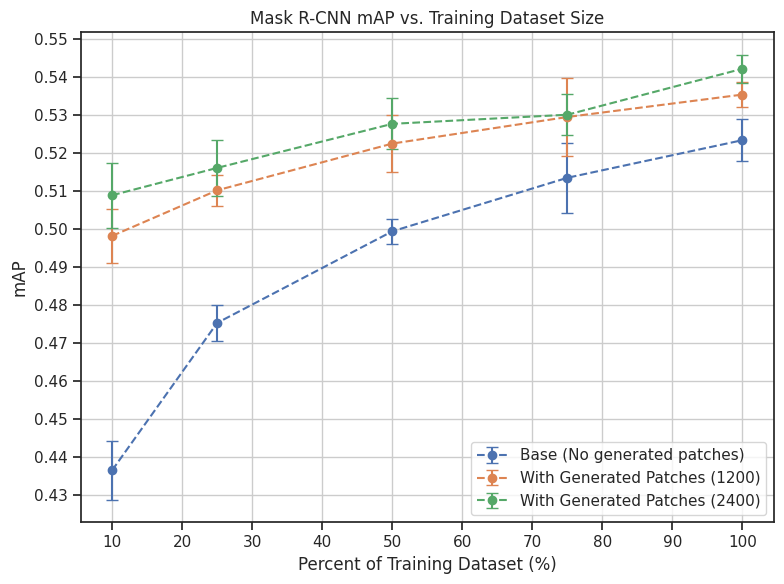

In [20]:
from matplotlib.ticker import MultipleLocator
sns.set_theme(style='ticks')

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(
    ds_sizes, mean_base,
    yerr=ci_base,
    fmt='--o',
    capsize=4,
    label='Base (No generated patches)'
)

ax.errorbar(
    ds_sizes, mean_gen_1200,
    yerr=ci_gen_1200,
    fmt='--o',
    capsize=4,
    label='With Generated Patches (1200)'
)

ax.errorbar(
    ds_sizes, mean_gen_2400,
    yerr=ci_gen_2400,
    fmt='--o',
    capsize=4,
    label='With Generated Patches (2400)'
)

ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(0.01))

ax.set_title("Mask R-CNN mAP vs. Training Dataset Size")
ax.set_xlabel("Percent of Training Dataset (%)")
ax.set_ylabel("mAP")

ax.grid()
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
from utils.config import PatchConfig
from utils.util import get_patches_2, create_neuron_structure
from collections import defaultdict
config = PatchConfig(stride=256, num_patches=24)

In [22]:
real_patches = get_patches_2(base_ds, config=config, filter_empty=True)

5744


In [23]:
gen_patches = [
    {
        "image": p['image'].astype(np.float32) / 255.0, 
        "mask": p['mask'], 
        "treatment": p['treatment'], 
        "region": p['region'],
    } for p in gen_ds]
len(gen_patches)

1248

In [24]:
from data.create_dataset import PatchDatasetComparison, NeuronPatchDataset

real_patch_ds = PatchDatasetComparison(real_patches)
gen_patch_ds = PatchDatasetComparison(gen_patches)

In [25]:
real_bg_stats = real_patch_ds.calc_patch_stats_df()
gen_bg_stats = gen_patch_ds.calc_patch_stats_df()

In [26]:
real_bg_stats['Source'] = 'Real'
gen_bg_stats['Source'] = 'Gen'
combined_df = pd.concat([real_bg_stats, gen_bg_stats], ignore_index=True)
combined_df = combined_df.sort_values(["Treatment", "Region"]).reset_index(drop=True)

In [27]:
combined_df.head(10)

,Treatment,Region,Cell Density,Cell Area,BG_R_mean,BG_G_mean,BG_B_mean,Stain_R_mean,Stain_G_mean,Stain_B_mean,Source
0,HI,CA12,0.000015,895.000000,0.549402,0.559734,0.553547,0.512148,0.428589,0.330212,Real
1,HI,CA12,0.000015,1151.000000,0.571075,0.582784,0.579842,0.534053,0.473657,0.415059,Real
2,HI,CA12,0.000015,694.000000,0.581731,0.590500,0.588831,0.540901,0.482493,0.440558,Real
3,HI,CA12,0.000015,1844.000000,0.581607,0.590746,0.589189,0.569053,0.548464,0.522571,Real
4,HI,CA12,0.000015,2785.000000,0.578229,0.581480,0.578110,0.526684,0.425910,0.319528,Real
5,HI,CA12,0.000031,1453.500000,0.574293,0.573422,0.569588,0.531999,0.447954,0.362135,Real
6,HI,CA12,0.000031,1610.500000,0.576653,0.585752,0.580286,0.546407,0.508859,0.458792,Real
7,HI,CA12,0.000046,966.333333,0.585397,0.589240,0.584680,0.567610,0.538431,0.500781,Real
8,HI,CA12,0.000015,911.000000,0.584187,0.589945,0.586227,0.550028,0.492072,0.424863,Real
9,HI,CA12,0.000031,344.000000,0.585699,0.587787,0.583220,0.548850,0.489129,0.430230,Real


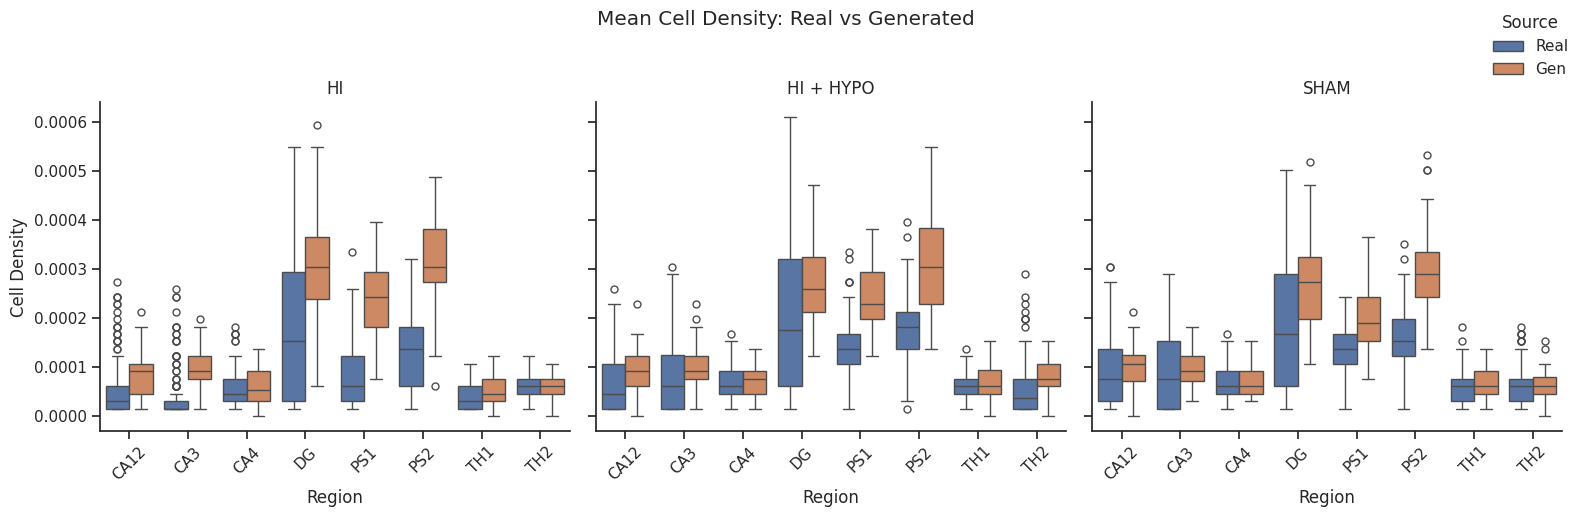

In [28]:
g = sns.catplot(
    data=combined_df,
    x="Region", y="Cell Density", hue="Source",
    col="Treatment", kind="box",
    height=5, aspect=1.0,
    palette={"Real": "#4C72B0", "Gen": "#DD8452"}
)

g.set_xticklabels(rotation=45)
g.set_titles("{col_name}")
g.fig.suptitle("Mean Cell Density: Real vs Generated", y=1.03)
sns.move_legend(g, "upper right")
plt.tight_layout()
plt.show()

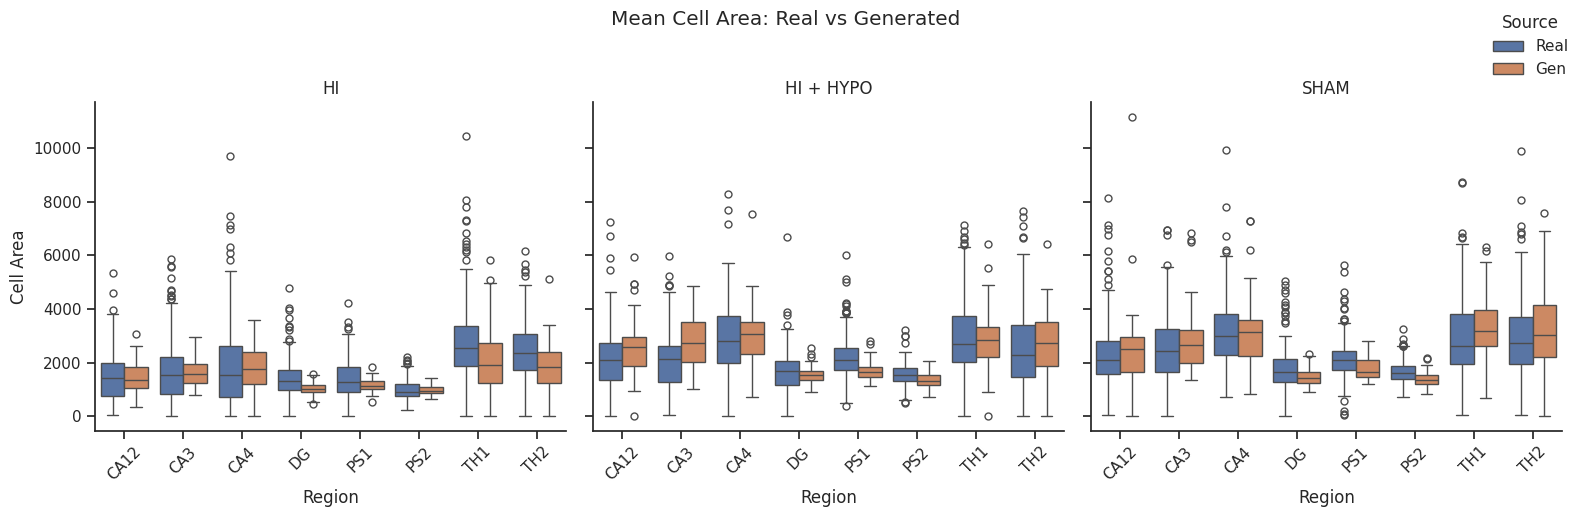

In [29]:
g = sns.catplot(
    data=combined_df,
    x="Region", y="Cell Area", hue="Source",
    col="Treatment", kind="box",
    height=5, aspect=1.0,
    palette={"Real": "#4C72B0", "Gen": "#DD8452"}
)

g.set_xticklabels(rotation=45)
g.set_titles("{col_name}")
g.fig.suptitle("Mean Cell Area: Real vs Generated", y=1.03)
sns.move_legend(g, "upper right")
plt.tight_layout()
plt.show()

In [30]:
bg_long = combined_df.melt(
    id_vars=["Source"],
    value_vars=["BG_R_mean", "BG_G_mean", "BG_B_mean"],
    var_name="Channel",
    value_name="BG Mean"
)

# clean up channel labels: "BG_R_mean" -> "R"
bg_long["Channel"] = bg_long["Channel"].str.extract(r"BG_(\w)_mean")

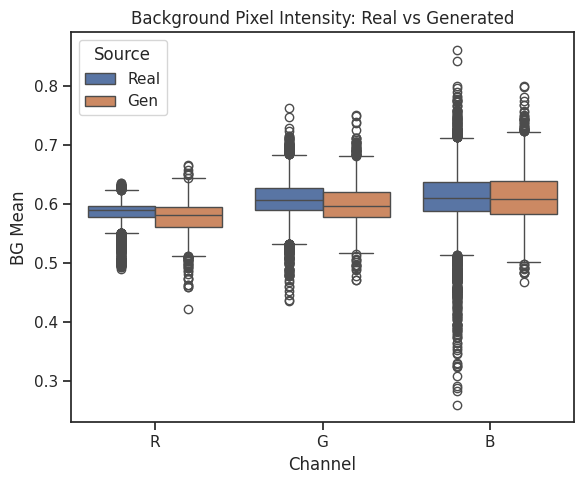

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data=bg_long, x="Channel", y="BG Mean", hue="Source",
    palette={"Real": "#4C72B0", "Gen": "#DD8452"},
    ax=ax
)
ax.set_title("Background Pixel Intensity: Real vs Generated")
plt.tight_layout()
plt.show()

In [32]:
bg_long = combined_df.melt(
    id_vars=["Source", "Treatment", "Region"],
    value_vars=["Stain_R_mean", "Stain_G_mean", "Stain_B_mean"],
    var_name="Channel",
    value_name="Stain Mean"
)
# clean up channel labels: "BG_R_mean" -> "R"
bg_long["Channel"] = bg_long["Channel"].str.extract(r"Stain_(\w)_mean")

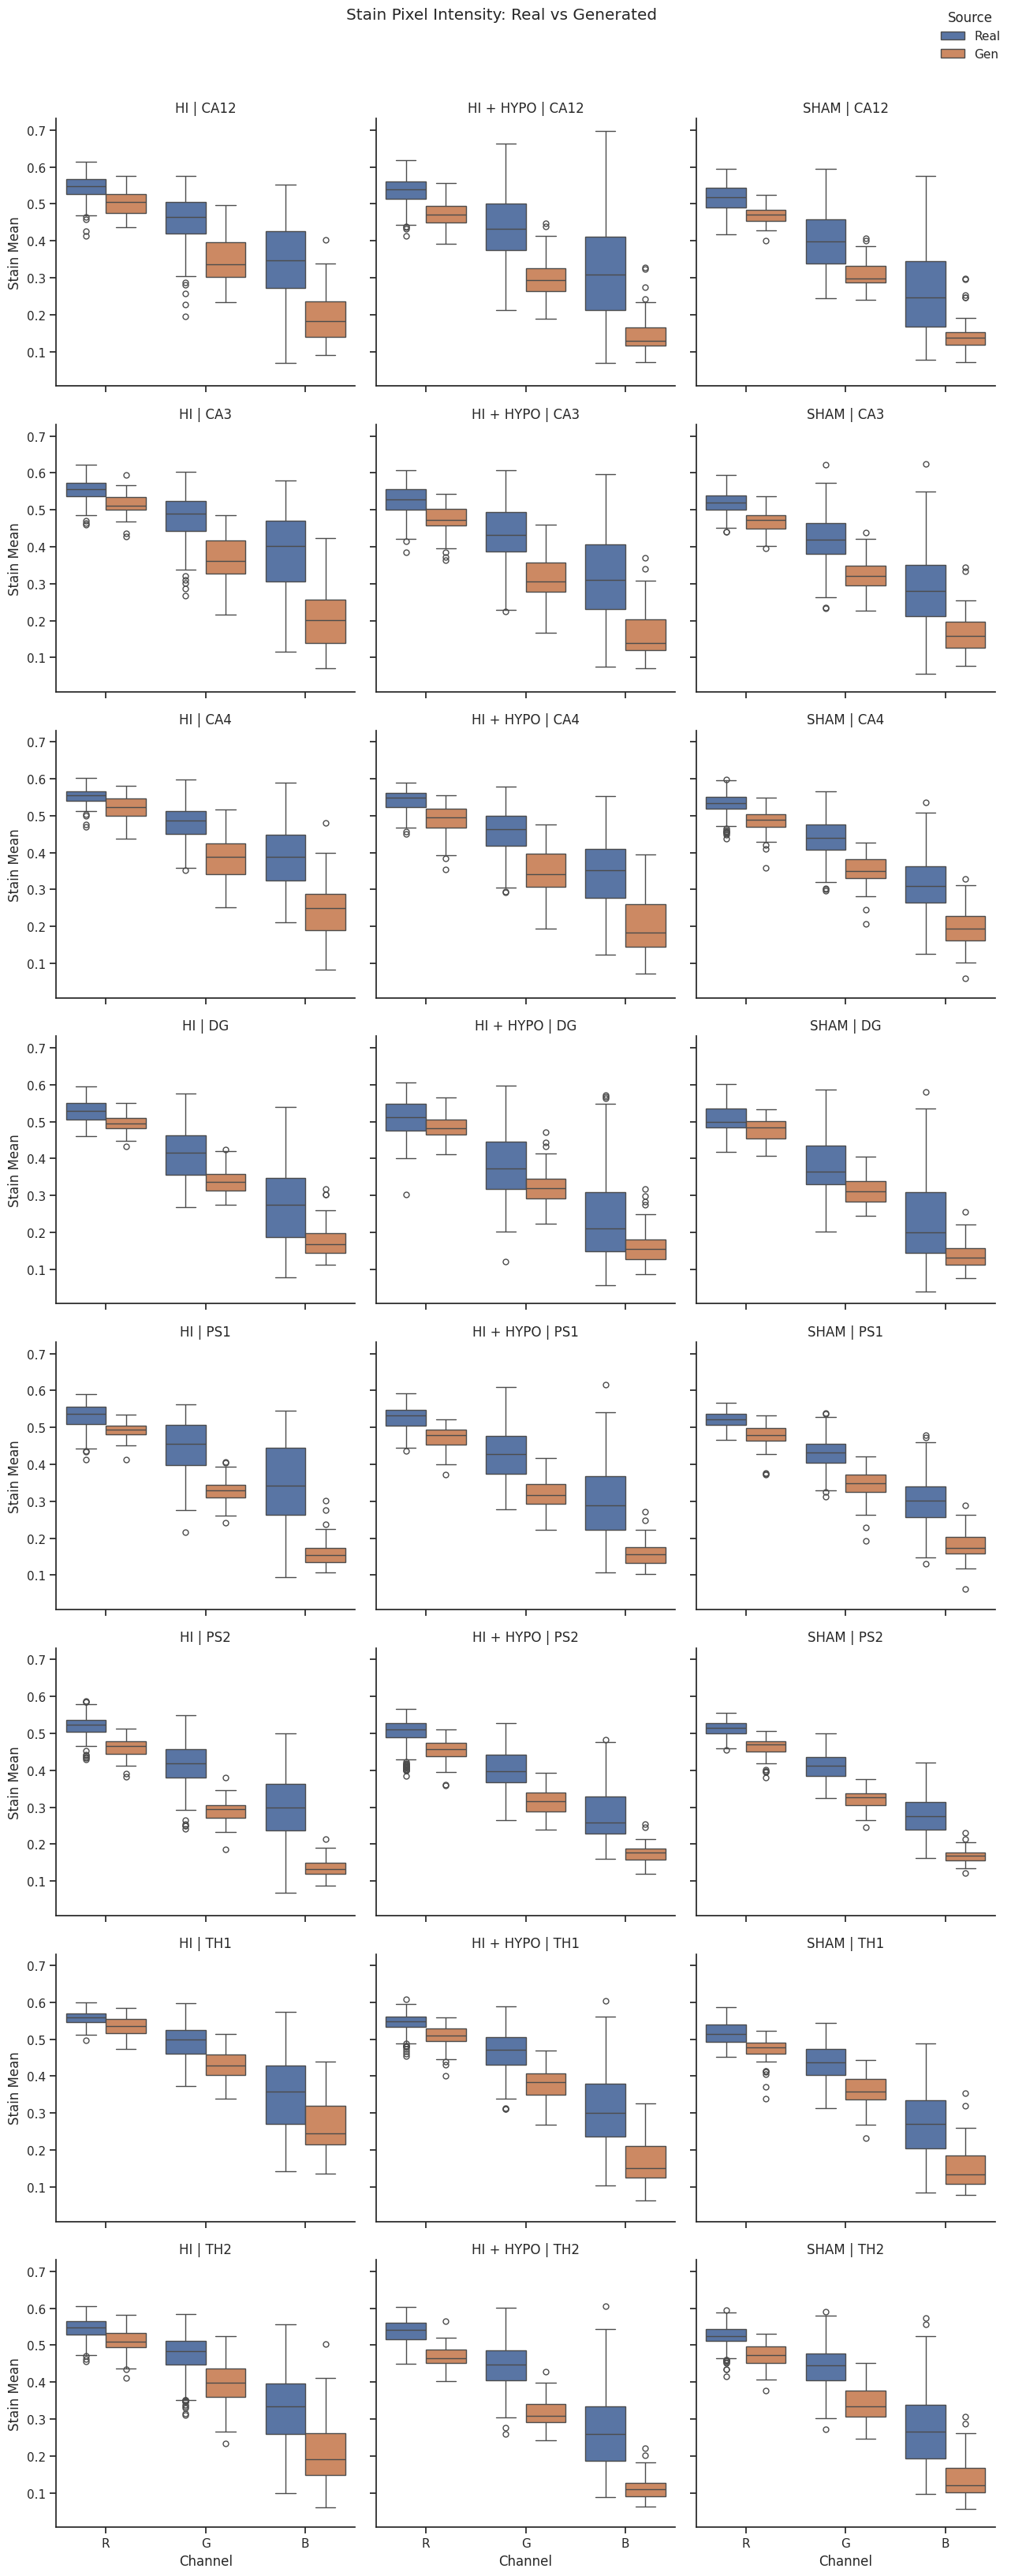

In [39]:
g = sns.catplot(
    data=bg_long,
    x="Channel", y="Stain Mean", hue="Source",
    col="Treatment", row="Region",
    kind="box",
    palette={"Real": "#4C72B0", "Gen": "#DD8452"},
    height=4, aspect=1
)
g.set_titles("{col_name} | {row_name}")
g.figure.suptitle("Stain Pixel Intensity: Real vs Generated", y=1.02)
plt.tight_layout()
sns.move_legend(g, 'upper right')
plt.show()

In [57]:
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

In [178]:
def calc_fid_kid_scores(real_ds, gen_ds, batch_size, device):
    fid = FrechetInceptionDistance(normalize=True).to(device)
    kid = KernelInceptionDistance(normalize=True, subset_size=50).to(device)

    def feed(dataset, metric, is_real):
        loader = DataLoader(dataset, batch_size=batch_size, collate_fn=lambda batch: batch)
        for batch in tqdm(loader):
            imgs = torch.stack([
                torch.from_numpy(patch['image']).permute(2, 0, 1)
                for patch in batch
            ]).to(device)
            metric.update(imgs, real=is_real)

    feed(real_ds, fid, is_real=True)
    feed(gen_ds, fid, is_real=False)
    fid_score = fid.compute().item()

    feed(real_ds, kid, is_real=True)
    feed(gen_ds, kid, is_real=False)
    kid_mean, kid_std = kid.compute()

    return {
        "fid": fid_score,
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item()
    }

In [179]:
scores = calc_fid_kid_scores(real_patches, gen_patches, batch_size=32, device=device)
scores

/hpc/ycao891/anaconda3/envs/summer-research/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
100%|██████████| 39/39 [00:02<00:00, 14.87it/s]


{'fid': 91.0008773803711,
 'kid_mean': 0.0755847692489624,
 'kid_std': 0.018707741051912308}

In [180]:
half = len(real_patches) // 2
real_list = list(real_patches)
random.shuffle(real_list)
real_a , real_b = real_list[:half], real_list[half:]

In [181]:
baseline_score = calc_fid_kid_scores(real_a, real_b, batch_size=32, device=device)
baseline_score

100%|██████████| 45/45 [00:03<00:00, 13.17it/s]


{'fid': 13.661983489990234,
 'kid_mean': -0.00018130541138816625,
 'kid_std': 0.003279882948845625}